### Efficacy of Gradient Boosting for Future Forecasts

/opt/homebrew/anaconda3/envs/text_analytics/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


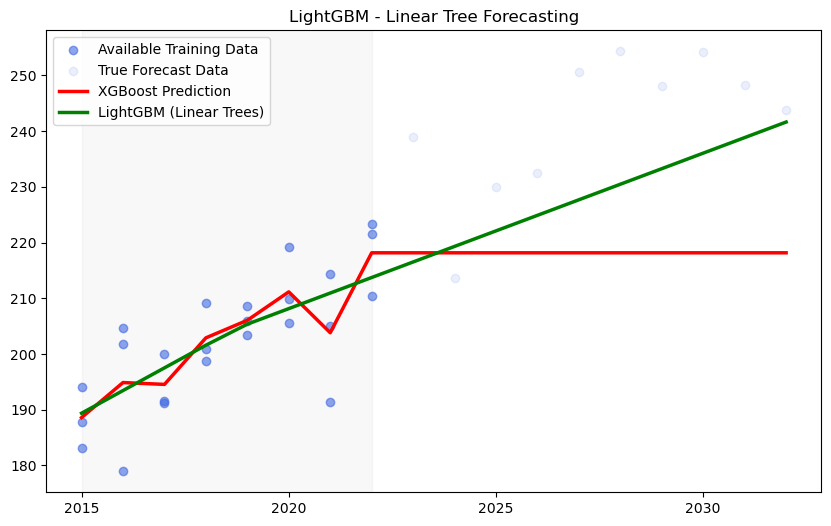

In [1]:
from lightgbm import LGBMRegressor
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt

# https://aaron-pickering.com/2025/04/21/xgboost-cant-extrapolate/

np.random.seed(0)
def true_fn(x):
    return 4 * np.log(x - 2014) + 4 * (x - 2015) + np.random.normal(0, 8, size = x.shape) + 180

training_years = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
forecast_years = [2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032]
 
x_train = np.repeat(training_years, 3).reshape(-1, 1)
y_train = true_fn(x_train.ravel())
x_forecast = np.repeat(forecast_years, 1).reshape(-1, 1)
y_forecast = true_fn(x_forecast.ravel())

x_full = np.concat([x_train, x_forecast])
y_true = np.concat([y_train, y_forecast])
 
LGBM = LGBMRegressor(n_estimators = 30, 
                     max_depth = 2, 
                     min_data_in_leaf = 10,
                     linear_tree = True, 
                     random_state = 42, 
                     verbose = -1)
LGBM.fit(x_train, y_train)
y_pred_LGBM = LGBM.predict(x_full)

XGB = xgb.XGBRegressor(n_estimators = 30, max_depth = 2, random_state = 42)
XGB.fit(x_train, y_train)
y_pred_XGB = XGB.predict(x_full)

plt.figure(figsize=(10, 6))
plt.title('LightGBM - Linear Tree Forecasting')
plt.axvspan(xmin = 2015, xmax = 2022, color = 'grey', alpha = 0.05)
plt.scatter(x_train, y_train, color = 'royalblue', label = 'Available Training Data', alpha = 0.6)
plt.scatter(x_forecast, y_forecast, color = 'royalblue', label = 'True Forecast Data', alpha = 0.1)
plt.plot(x_full, y_pred_XGB, color = 'red', linewidth = 2.5, label = 'XGBoost Prediction')
plt.plot(x_full, y_pred_LGBM, color = 'green', linewidth = 2.5, label = 'LightGBM (Linear Trees)')
plt.xticks(np.arange(2015, 2031, 5))
plt.legend(loc = 'upper left')
plt.show()